In [1]:
COUNTRIES = {
    'Belgium': [(2000, 2012), (2014, 2024)],
    'Germany': [(2000, 2012), (2014, 2024)], #very low data coverage
    'Italy': [(2000, 2012), (2014, 2024)],
    'Portugal': [None, (2014, 2024)], #no data for first period
    'Spain':[(2000, 2012), (2014, 2024)],
    'Sweden': [(2000, 2012), (2014, 2024)]

}

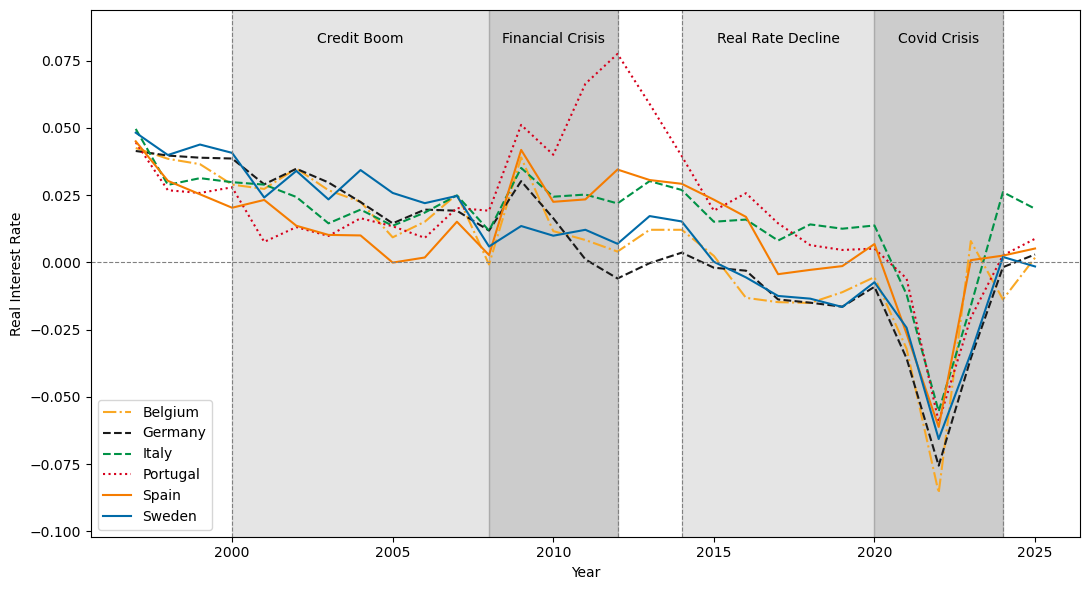

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from modules.RealRate import RealRate
from CompareCountries import COUNTRY_STYLES

df = pd.DataFrame()
for country in COUNTRIES.keys():
    rr = RealRate(country)
    df = pd.concat([df, rr.df], axis=0, ignore_index=True)



fig, ax = plt.subplots(figsize=(11, 6))

for country, g in df.groupby('country'):
    color = COUNTRY_STYLES.get(country)['color']
    linestyle = COUNTRY_STYLES.get(country)['linestyle']
    ax.plot(g['year'], g['realinterestrate'], color=color, label=country, linestyle=linestyle)

ax.axvline(2000, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2012, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2014, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2024, color='grey', linewidth=0.8, linestyle='--')

ax.axvspan(2000, 2008, color='gray', alpha=0.2)
ax.text((2000 + 2008) / 2, ax.get_ylim()[1], 'Credit Boom', ha='center', va='top')

ax.axvspan(2008, 2012, color='gray', alpha=0.4)
ax.text((2008 + 2012) / 2, ax.get_ylim()[1], 'Financial Crisis', ha='center', va='top')

ax.axvspan(2014, 2020, color='gray', alpha=0.2)
ax.text((2014 + 2020) / 2, ax.get_ylim()[1], 'Real Rate Decline', ha='center', va='top')

ax.axvspan(2020, 2024, color='gray', alpha=0.4)
ax.text((2020 + 2024) / 2, ax.get_ylim()[1], 'Covid Crisis', ha='center', va='top')


ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Real Interest Rate')
ax.legend()
ax.margins(x=0.05, y=0.1)  
fig.tight_layout()
plt.show()


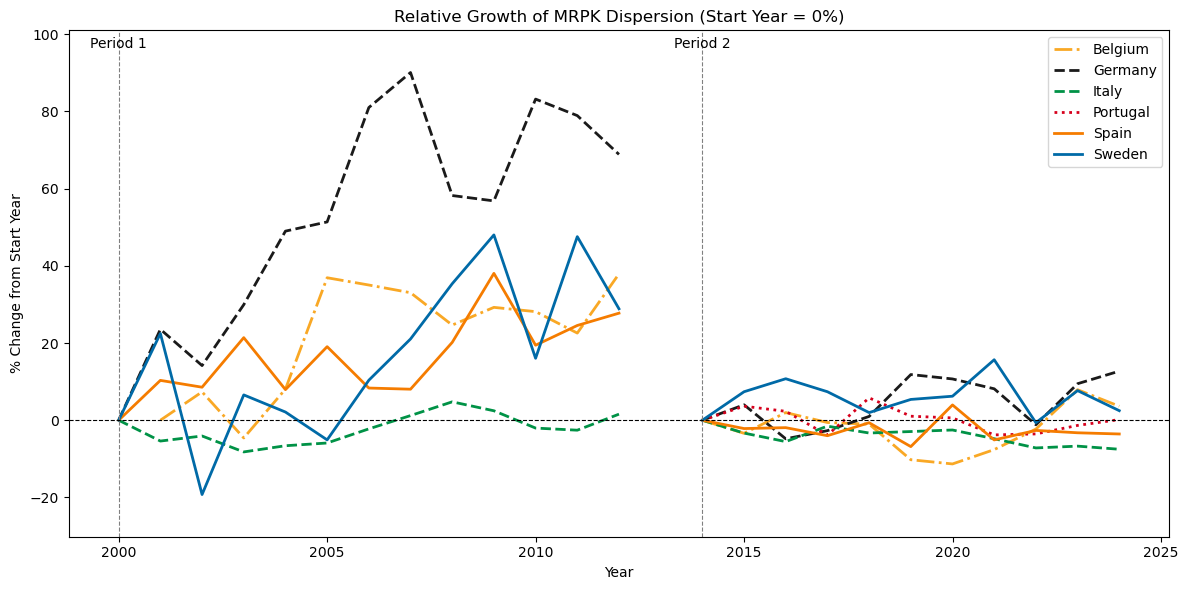

,Country,Time,Revenue Data Coverage %,Change Real Interest Rate %,Increase in Real Interest Rate %,Decrease in Real Interest Rate %,Change log MRPK %,Increase in MRPK %,Decrease in MRPK %,Coef log_a on capital growth,P-Value Coefficient
0,Belgium,2000 - 2012,43.18,-2.49,6.34,-8.83,38.02,63.47,-25.45,0.048,0.006
1,Belgium,2014 - 2024,34.36,-2.59,10.32,-12.91,5.12,25.94,-20.82,0.045,0.009
2,Germany,2000 - 2012,6.31,-4.46,2.93,-7.39,61.81,95.01,-33.20,0.039,0.883
3,Germany,2014 - 2024,6.18,-0.54,8.12,-8.66,14.07,34.48,-20.41,0.026,0.036
4,Italy,2000 - 2012,31.00,-0.79,4.05,-4.84,2.25,19.08,-16.83,-3.115,0.000
5,Italy,2014 - 2024,42.09,-0.08,8.95,-9.03,-7.55,5.55,-13.10,0.021,0.000
6,Portugal,2014 - 2024,37.73,-3.69,6.89,-10.58,1.15,17.75,-16.60,0.041,0.000
7,Spain,2000 - 2012,61.92,1.42,6.92,-5.50,29.94,65.38,-35.44,0.026,0.000
8,Spain,2014 - 2024,59.09,-2.67,7.49,-10.16,-2.26,17.90,-20.16,0.034,0.000
9,Sweden,2000 - 2012,13.77,-3.38,3.33,-6.71,49.15,128.68,-79.53,0.047,0.000


In [ ]:
from CompareCountries import CompareCountries
from MisallocationAnalysis import MisallocationAnalysis

allanalises = []

for country, rangelist in COUNTRIES.items():
    for range in rangelist:
        if range == None:
            continue
        analysis = MisallocationAnalysis(country, range[0], range[1], sector='C')
        allanalises.append(analysis)


comparison = CompareCountries(allanalises)
countriesmrpkplot = comparison.plot_compare_mrpk()
comparison.compare()



In [5]:
comparison.compare_all_moments()

,Belgium 2000-2012,Belgium 2014-2024,Germany 2000-2012,Germany 2014-2024,Italy 2000-2012,Italy 2014-2024,Portugal 2014-2024,Spain 2000-2012,Spain 2014-2024,Sweden 2000-2012,Sweden 2014-2024
Std.dev.(log Z_pow),2.010,2.190,2.280,1.850,2.110,2.030,2.270,2.460,2.300,2.460,2.340
Std.dev.(log k),1.540,1.580,1.850,1.300,1.600,1.650,1.710,2.000,1.870,1.920,1.900
Std.dev.(log l),1.530,1.510,1.680,1.210,1.660,1.780,1.620,1.750,1.680,1.910,1.940
Top 20% Share of l,0.810,0.790,0.760,0.670,0.770,0.820,0.810,0.820,0.810,0.850,0.840
Top 20% Share of k,0.850,0.860,0.820,0.770,0.790,0.850,0.870,0.870,0.880,0.910,0.900
Coef log_Z on capital growth,0.041,0.044,-0.086,0.026,-2.638,0.011,0.023,0.034,0.032,0.051,0.043
Coef log_a on capital growth,0.048,0.045,0.039,0.026,-3.115,0.021,0.041,0.026,0.034,0.047,0.020
Coef log_k on capital growth,-0.924,-0.747,-3.790,-0.675,-46.785,-0.813,-0.920,-0.919,-0.730,-1.033,-0.861
Coef log_Z on capital growth t_0 - T,0.105,0.050,0.128,0.075,-1.780,0.020,0.032,0.036,0.031,0.355,0.040
Coef log_a on capital growth t_0 - T,0.091,0.034,0.108,0.064,-1.540,0.018,0.042,0.019,0.037,0.138,0.015


In [ ]:
ds = comparison.descriptive_statistics()
os = comparison.overview_statistics()

AttributeError: 'MisallocationAnalysis' object has no attribute 'distributional_moments'